Method POD

Avec une situation que j'ai créée

Matrice snapshots : (998, 98)
   90.0 % d'énergie → r =  3 modes / 98
   99.0 % d'énergie → r =  3 modes / 98
   99.9 % d'énergie → r =  4 modes / 98

Reconstruction avec r=5 : erreur relative = 1.58%


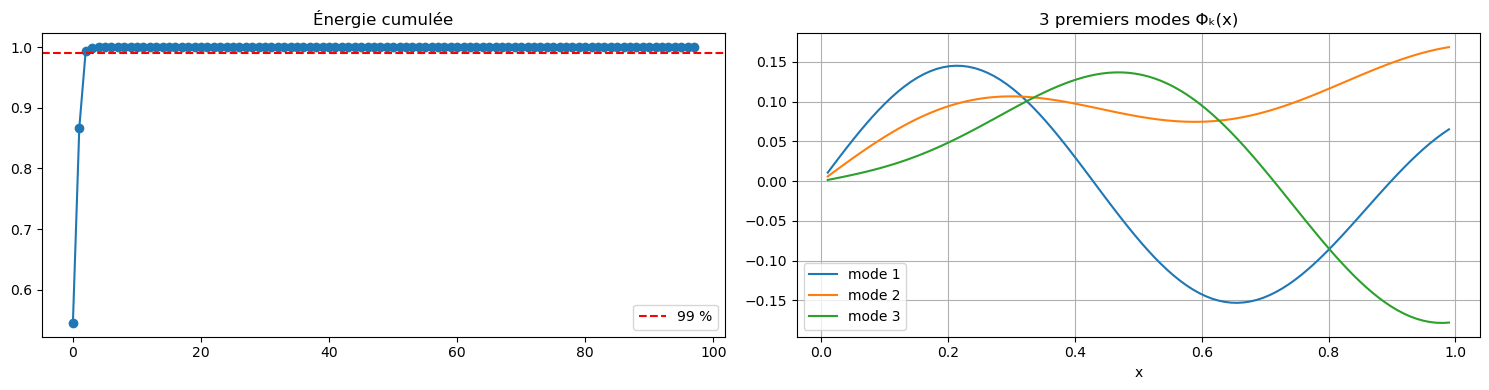

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("wave_beam_dataset.csv")


mask  = (df["A"] == 0.005) & (df["omega"] == 7)       #we test on a simulation we have computed
Nx_i  = df.loc[mask, "x"].nunique()                 # nb de nœuds intérieurs
U     = df.loc[mask, "u"].values.reshape(-1, Nx_i)  # lignes = temps, cols = x


print(f"Matrice snapshots : {U.shape}")


U_mean   = U.mean(axis=0)                           # snapshot moyen
_, S, Vt = np.linalg.svd(U - U_mean, full_matrices=False)
modes    = Vt.T                                     # colonnes = Φ_k(x)


# 3. Énergie cumulée → combien de modes garder ?
cum_energy = np.cumsum(S**2) / np.sum(S**2)
for tol in [0.90, 0.99, 0.999] :
    r = np.searchsorted(cum_energy, tol) + 1
    print(f"  {tol*100:5.1f} % d'énergie → r = {r:>2d} modes / {len(S)}")


# 4. Reconstruction avec r modes
r      = 5                                          # à ajuster
coefs  = (U - U_mean) @ modes[:, :r]                # coefs[i, k] = a_k(t_i)
U_rec  = coefs @ modes[:, :r].T + U_mean            # reconstruction
err    = np.linalg.norm(U - U_rec) / np.linalg.norm(U)
print(f"\nReconstruction avec r={r} : erreur relative = {err:.2%}")

# 5. Visualisations
fig, ax = plt.subplots(1, 2, figsize=(15, 4))

ax[0].plot(cum_energy, "o-")                        # énergie cumulée
ax[0].axhline(0.99, color="red", ls="--", label="99 %")
ax[0].set_title("Énergie cumulée") ; ax[1].set_xlabel("r")
ax[0].legend() ; ax[1].grid(True)

x_grid = np.sort(df.loc[mask, "x"].unique())        # 3 premiers modes spatiaux
for k in range(3):
    ax[1].plot(x_grid, modes[:, k], label=f"mode {k+1}")
ax[1].set_title("3 premiers modes Φₖ(x)") ; ax[1].set_xlabel("x")
ax[1].legend() ; ax[1].grid(True)

plt.tight_layout() ; plt.show()

Avec l'exemple de la poutre

Matrice snapshots : (998, 98)
   90.0 % d'énergie → r =  3 modes / 98
   99.0 % d'énergie → r =  3 modes / 98
   99.9 % d'énergie → r =  4 modes / 98

Reconstruction avec r=5 : erreur relative = 1.58%


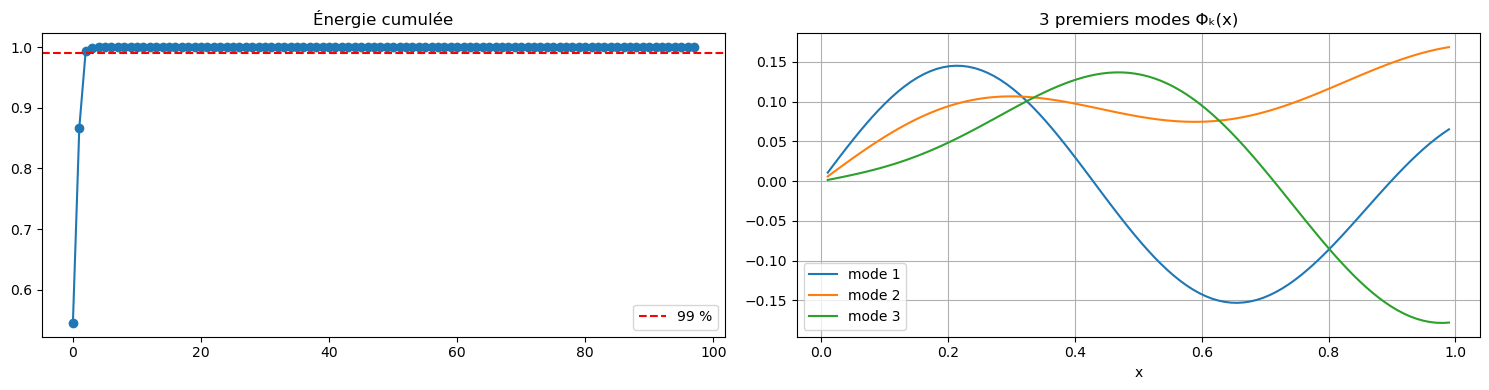

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("wave_beam_dataset.csv")


mask  = (df["A"] == 0.005) & (df["omega"] == 7)       #we test on a simulation we have computed
Nx_i  = df.loc[mask, "x"].nunique()                 # nb de nœuds intérieurs
U     = df.loc[mask, "u"].values.reshape(-1, Nx_i)  # lignes = temps, cols = x


print(f"Matrice snapshots : {U.shape}")


U_mean   = U.mean(axis=0)                           # snapshot moyen
_, S, Vt = np.linalg.svd(U - U_mean, full_matrices=False)
modes    = Vt.T                                     # colonnes = Φ_k(x)


# 3. Énergie cumulée → combien de modes garder ?
cum_energy = np.cumsum(S**2) / np.sum(S**2)
for tol in [0.90, 0.99, 0.999] :
    r = np.searchsorted(cum_energy, tol) + 1
    print(f"  {tol*100:5.1f} % d'énergie → r = {r:>2d} modes / {len(S)}")


# 4. Reconstruction avec r modes
r      = 5                                          # à ajuster
coefs  = (U - U_mean) @ modes[:, :r]                # coefs[i, k] = a_k(t_i)
U_rec  = coefs @ modes[:, :r].T + U_mean            # reconstruction
err    = np.linalg.norm(U - U_rec) / np.linalg.norm(U)
print(f"\nReconstruction avec r={r} : erreur relative = {err:.2%}")


# 5. Visualisations
fig, ax = plt.subplots(1, 2, figsize=(15, 4))

ax[0].plot(cum_energy, "o-")                        # énergie cumulée
ax[0].axhline(0.99, color="red", ls="--", label="99 %")
ax[0].set_title("Énergie cumulée") ; ax[1].set_xlabel("r")
ax[0].legend() ; ax[1].grid(True)

x_grid = np.sort(df.loc[mask, "x"].unique())        # 3 premiers modes spatiaux
for k in range(3):
    ax[1].plot(x_grid, modes[:, k], label=f"mode {k+1}")
ax[1].set_title("3 premiers modes Φₖ(x)") ; ax[1].set_xlabel("x")
ax[1].legend() ; ax[1].grid(True)

plt.tight_layout() ; plt.show()

Method DMD

Method Autoencoder non-linéaire